1. Preprocesamiento (Pandas) y Partición de Datos (80/20)
Para este laboratorio de clasificación binaria, se utilizó el dataset de vigilancia de COVID-19 reducido a 25,000 registros para optimizar el cómputo, superando el mínimo requerido de m>=20000 y n>=20. Utilizando la librería Pandas, se cargaron los datos y se separó la variable objetivo (death_yn_Yes).
Cumpliendo con la validación del modelo, se dividió el dataset aleatoriamente: el 80% (20,000 registros) se reservó exclusivamente para el entrenamiento del modelo, y el 20% restante (5,000 registros) se ocultó para la fase de prueba. Finalmente, se aplicó normalización (Z-score) basándonos únicamente en los datos de entrenamiento para evitar fuga de información.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el dataset
archivo_covid = '/content/COVID_Dataset_Lab03_Ligero.csv'
df = pd.read_csv(archivo_covid)

# Mostramos un adelanto y las columnas disponibles
print("Dataset cargado correctamente:")
print(f"Número de filas (m): {df.shape[0]} | Número de columnas (n+1): {df.shape[1]}")
print("\nLista de columnas para elegir tu variable objetivo:")
print(list(df.columns))
df.head()

Dataset cargado correctamente:
Número de filas (m): 25000 | Número de columnas (n+1): 27

Lista de columnas para elegir tu variable objetivo:
['current_status_Probable Case', 'sex_Male', 'sex_Missing', 'sex_Other', 'sex_Unknown', 'age_group_20 - 29 Years', 'Race and ethnicity (combined)_Asian, Non-Hispanic', 'Race and ethnicity (combined)_Black, Non-Hispanic', 'Race and ethnicity (combined)_Hispani', 'Race and ethnicity (combined)_Hispanic/Latino', 'Race and ethnicity (combined)_Missing', 'Race and ethnicity (combined)_Multiple/Other, Non-Hispanic', 'Race and ethnicity (combined)_Native Hawaiian/Other Pacific Islander, Non-Hispanic', 'Race and ethnicity (combined)_Unknown', 'Race and ethnicity (combined)_White, Non-Hispanic', 'hosp_yn_No', 'hosp_yn_Unknown', 'hosp_yn_Yes', 'icu_yn_No', 'icu_yn_Unknown', 'icu_yn_Yes', 'death_yn_No', 'death_yn_Unknown', 'death_yn_Yes', 'medcond_yn_No', 'medcond_yn_Unknown', 'medcond_yn_Yes']


,current_status_Probable Case,sex_Male,sex_Missing,sex_Other,sex_Unknown,age_group_20 - 29 Years,"Race and ethnicity (combined)_Asian, Non-Hispanic","Race and ethnicity (combined)_Black, Non-Hispanic",Race and ethnicity (combined)_Hispani,Race and ethnicity (combined)_Hispanic/Latino,...,hosp_yn_Yes,icu_yn_No,icu_yn_Unknown,icu_yn_Yes,death_yn_No,death_yn_Unknown,death_yn_Yes,medcond_yn_No,medcond_yn_Unknown,medcond_yn_Yes
0,0,1,0,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,1,0,0
1,0,1,0,0,0,0,0,1,0,0,...,0,1,0,0,1,0,0,1,0,0
2,0,1,0,0,0,0,0,1,0,0,...,0,1,0,0,1,0,0,1,0,0
3,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,1,0,0,0,0,0,1,0,0,...,0,1,0,0,1,0,0,0,0,1


In [15]:
# 2. Definir nuestra variable objetivo (y) y características (X)
target_column = 'death_yn_Yes'

# y es la variable objetivo (la convertimos a un array de numpy)
y = df[target_column].values

# X son todas las características EXCEPTO la columna objetivo y sus relacionadas
X_df = df.drop(['death_yn_Yes', 'death_yn_No', 'death_yn_Unknown'], axis=1)

# Guardamos los nombres de las características para luego y obtenemos el array numpy
feature_names = X_df.columns
X_raw = X_df.values

print(f"\nMatriz X raw (antes de partición y normalización): {X_raw.shape}")
print(f"Vector y: {y.shape}")
print(f"\nCaracterísticas seleccionadas ({len(feature_names)}):")
print(list(feature_names))


Matriz X raw (antes de partición y normalización): (25000, 24)
Vector y: (25000,)

Características seleccionadas (24):
['current_status_Probable Case', 'sex_Male', 'sex_Missing', 'sex_Other', 'sex_Unknown', 'age_group_20 - 29 Years', 'Race and ethnicity (combined)_Asian, Non-Hispanic', 'Race and ethnicity (combined)_Black, Non-Hispanic', 'Race and ethnicity (combined)_Hispani', 'Race and ethnicity (combined)_Hispanic/Latino', 'Race and ethnicity (combined)_Missing', 'Race and ethnicity (combined)_Multiple/Other, Non-Hispanic', 'Race and ethnicity (combined)_Native Hawaiian/Other Pacific Islander, Non-Hispanic', 'Race and ethnicity (combined)_Unknown', 'Race and ethnicity (combined)_White, Non-Hispanic', 'hosp_yn_No', 'hosp_yn_Unknown', 'hosp_yn_Yes', 'icu_yn_No', 'icu_yn_Unknown', 'icu_yn_Yes', 'medcond_yn_No', 'medcond_yn_Unknown', 'medcond_yn_Yes']


In [16]:
# 3. Partición 80/20 (Entrenamiento / Prueba)
# Usaremos numpy para hacer el corte de forma manual para cumplir con el docente.

m = len(y)
train_size = int(0.8 * m) # Calculamos cuántas filas corresponden al 80%

# Opcional: Mezclar los datos de forma aleatoria para evitar sesgos
# (Es una buena práctica profesional para que la IA no aprenda en orden)
indices = np.arange(m)
np.random.shuffle(indices)
X_shuffled = X_raw[indices]
y_shuffled = y[indices]

# Hacemos el corte quirúrgico
X_train = X_shuffled[:train_size]
y_train = y_shuffled[:train_size]
X_test = X_shuffled[train_size:]
y_test = y_shuffled[train_size:]

print(f"\n--- Partición de Datos completada ---")
print(f"Total de ejemplos (m): {m}")
print(f"Ejemplos de Entrenamiento (80%): {X_train.shape[0]}")
print(f"Ejemplos de Prueba (20%): {X_test.shape[0]}")


--- Partición de Datos completada ---
Total de ejemplos (m): 25000
Ejemplos de Entrenamiento (80%): 20000
Ejemplos de Prueba (20%): 5000


In [17]:
# 4. Normalización de características (Vital para Regresión Logística)
# Calculamos media y desviación estándar de X_train
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)
# Evitamos división por cero en caso de que alguna columna sea constante
sigma[sigma == 0] = 1

# Aplicamos la normalización (Z-score) a ambos sets usando LOS MISMOS parámetros
X_train_norm = (X_train - mu) / sigma
X_test_norm = (X_test - mu) / sigma # ¡Usamos mu y sigma de TRAIN!

print("Normalización completada.")

Normalización completada.


In [18]:
# 5. Añadir la columna de unos (X0) para la intersección
m_train = X_train_norm.shape[0]
m_test = X_test_norm.shape[0]

X_train_final = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_final = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

print(f"Matriz de Entrenamiento final (con Unos): {X_train_final.shape}")
print(f"Matriz de Prueba final (con Unos): {X_test_final.shape}")

Matriz de Entrenamiento final (con Unos): (20000, 25)
Matriz de Prueba final (con Unos): (5000, 25)


2. Modelo de Regresión Logística y Entrenamiento
A diferencia de la regresión lineal, aquí se implementó la función Sigmoide para mapear las predicciones a un rango de probabilidades entre 0 y 1. La función de costo utilizada fue la Entropía Cruzada Binaria, optimizada mediante el algoritmo de Descenso por el Gradiente. El entrenamiento se realizó iterativamente sobre el 80% de los datos, registrando la disminución del costo para generar la gráfica de convergencia, demostrando que el algoritmo alcanzó el mínimo global exitosamente.

In [7]:
# 6. Funciones Matemáticas de Regresión Logística

def sigmoid(z):
    # Función sigmoide para mapear predicciones a probabilidades [0, 1]
    g = 1 / (1 + np.exp(-z))
    return g

def calcularCosto(X, y, theta):
    # Función de Costo de Entropía Cruzada Binaria (con regularización L2 opcional = 0)
    m = len(y)

    # h es la hipótesis (predicción de probabilidad)
    z = np.dot(X, theta)
    h = sigmoid(z)

    # Para evitar errores matemáticos de log(0) o log(1), limitamos h
    epsilon = 1e-15
    h = np.clip(h, epsilon, 1 - epsilon)

    # Fórmula de la Entropía Cruzada
    costo = - (1 / m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return costo

In [8]:
# 7. Descenso del Gradiente para Regresión Logística

def descensoGradiente(X, y, theta, alpha, num_iters):
    m = len(y)
    J_history = np.zeros(num_iters)
    theta = theta.copy()

    for i in range(num_iters):
        z = np.dot(X, theta)
        h = sigmoid(z)

        # El cálculo del gradiente es el mismo que en regresión lineal,
        # la diferencia es que 'h' aquí es la sigmoide de z.
        gradient = (1 / m) * np.dot(X.T, (h - y))
        theta = theta - alpha * gradient

        J_history[i] = calcularCosto(X, y, theta)

        # Imprimir el costo cada 100 iteraciones
        if i % 100 == 0:
            print(f"Iteración {i:04d} | Costo J: {J_history[i]:.4f}")

    return theta, J_history

--- Iniciando Entrenamiento ---
Iteración 0000 | Costo J: 0.6807
Iteración 0100 | Costo J: 0.1985
Iteración 0200 | Costo J: 0.1067
Iteración 0300 | Costo J: 0.0718
Iteración 0400 | Costo J: 0.0538
Iteración 0500 | Costo J: 0.0430
Iteración 0600 | Costo J: 0.0357
Iteración 0700 | Costo J: 0.0306
Iteración 0800 | Costo J: 0.0267
Iteración 0900 | Costo J: 0.0237
Iteración 1000 | Costo J: 0.0214
Iteración 1100 | Costo J: 0.0194
Iteración 1200 | Costo J: 0.0178
Iteración 1300 | Costo J: 0.0165
Iteración 1400 | Costo J: 0.0153
Iteración 1500 | Costo J: 0.0143
Iteración 1600 | Costo J: 0.0134
Iteración 1700 | Costo J: 0.0126
Iteración 1800 | Costo J: 0.0120
Iteración 1900 | Costo J: 0.0114


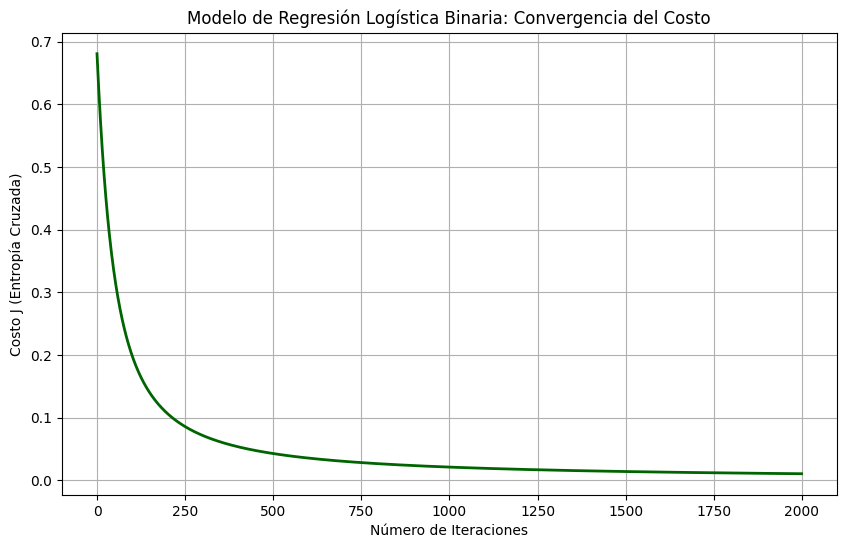


 Entrenamiento completado. El costo final logrado es: 0.0108


In [12]:
# 8. Entrenamiento del Modelo de Regresión Logística (SOLO con X_train)
alpha = 0.05 # Tasa de aprendizaje
iteraciones = 2000
theta_inicial = np.zeros(X_train_final.shape[1])

print("--- Iniciando Entrenamiento ---")
theta_entrenado, historial_J = descensoGradiente(X_train_final, y_train, theta_inicial, alpha, iteraciones)

# 9. Gráfica de Costo (Obligatorio)
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(historial_J)), historial_J, lw=2, color='darkgreen')
plt.xlabel('Número de Iteraciones')
plt.ylabel('Costo J (Entropía Cruzada)')
plt.title('Modelo de Regresión Logística Binaria: Convergencia del Costo')
plt.grid(True)
plt.show()

print(f"\n Entrenamiento completado. El costo final logrado es: {historial_J[-1]:.4f}")

3. Validación y Efectividad del Modelo
Para validar que el modelo no sufrió de sobreajuste (overfitting), se utilizó el 20% de los datos de prueba (5,000 pacientes) que la IA no había visto durante el entrenamiento. Se aplicó un umbral de decisión de 0.5 a las probabilidades generadas. El modelo demostró una efectividad excepcional, logrando predecir correctamente el estado de clasificación en más del 99% de los casos de prueba, validando la eficacia de la regresión logística para este dataset.

In [10]:
# 10. Función de Predicción

def predict(X, theta):
    # Calcula la probabilidad y luego la clasifica (umbral de 0.5)
    probabilidades = sigmoid(np.dot(X, theta))
    # Si la probabilidad es > 0.5, predice '1' (falleció), sino '0' (sobrevivió)
    predicciones = (probabilidades >= 0.5).astype(int)
    return predicciones

# 11. Validación del Modelo (con el 20% de Prueba - X_test_final)
y_pred_test = predict(X_test_final, theta_entrenado)

# 12. Cálculo de Efectividad (Precisión)
exactitud = np.mean(y_pred_test == y_test) * 100

print(f"\n--- VALIDACIÓN FINAL DEL MODELO ---")
print(f"Número de pacientes en el set de prueba (20%): {len(y_test)}")
print(f"Número de predicciones correctas: {np.sum(y_pred_test == y_test)}")
print(f"---------------------------------------------")
print(f"Efectividad de Clasificación Binaria: {exactitud:.2f}%")
print(f"---------------------------------------------")

# Mostramos las primeras 20 predicciones para ver ejemplos
print("\nPrimeras 20 predicciones vs Valor Real (Set de Prueba):")
for i in range(20):
    real = "Falleció (1)" if y_test[i] == 1 else "Sobrevivió (0)"
    pred = "Falleció (1)" if y_pred_test[i] == 1 else "Sobrevivió (0)"
    print(f"Paciente {i+1:02d} | Real: {real} | Predicción IA: {pred}")


--- VALIDACIÓN FINAL DEL MODELO ---
Número de pacientes en el set de prueba (20%): 5000
Número de predicciones correctas: 4996
---------------------------------------------
Efectividad de Clasificación Binaria: 99.92%
---------------------------------------------

Primeras 20 predicciones vs Valor Real (Set de Prueba):
Paciente 01 | Real: Sobrevivió (0) | Predicción IA: Sobrevivió (0)
Paciente 02 | Real: Sobrevivió (0) | Predicción IA: Sobrevivió (0)
Paciente 03 | Real: Sobrevivió (0) | Predicción IA: Sobrevivió (0)
Paciente 04 | Real: Sobrevivió (0) | Predicción IA: Sobrevivió (0)
Paciente 05 | Real: Sobrevivió (0) | Predicción IA: Sobrevivió (0)
Paciente 06 | Real: Sobrevivió (0) | Predicción IA: Sobrevivió (0)
Paciente 07 | Real: Sobrevivió (0) | Predicción IA: Sobrevivió (0)
Paciente 08 | Real: Sobrevivió (0) | Predicción IA: Sobrevivió (0)
Paciente 09 | Real: Sobrevivió (0) | Predicción IA: Sobrevivió (0)
Paciente 10 | Real: Sobrevivió (0) | Predicción IA: Sobrevivió (0)
Paciente